In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, mean_absolute_error, classification_report
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
import os
import time
from datetime import timedelta
import sys
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [3]:
class CEFRDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx]) - 1

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [4]:
df = pd.read_csv('ru_cefr_short.csv')
df['label'] = df['textbook-assigned cefr level'].astype(int)
df

,fragment,textbook-assigned cefr level,label
0,"Весной, летом и осенью почти каждую субботу он...",1,1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1,1
2,На каждой двери красные плакаты и красные фона...,1,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1,1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1,1
...,...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6,6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6,6
7320,Mapillary использует программное обеспечение д...,6,6


In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['fragment'].values,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Размер обучающей выборки без аугментаций: {len(train_texts)}")
print(f"Размер валидационной выборки без аугментаций: {len(val_texts)}")

Размер обучающей выборки без аугментаций: 5857
Размер валидационной выборки без аугментаций: 1465


In [6]:
def fit(c2):
    model_name = 'sberbank-ai/ruBert-large'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=6,
        id2label={0: 'A1', 1: 'A2', 2: 'B1', 3: 'B2', 4: 'C1', 5: 'C2'},
        label2id={'A1': 0, 'A2': 1, 'B1': 2, 'B2': 3, 'C1': 4, 'C2': 5}
    )
    
    model = model.to(device)
    print(f"Модель инициализирована")

    
    train_labels_aug = train_labels.tolist() + [6]*len(c2)
    train_texts_aug = train_texts.tolist() + c2['augmented-text'].tolist()
    
    train_dataset = CEFRDataset(train_texts_aug, train_labels_aug, tokenizer)
    val_dataset = CEFRDataset(val_texts, val_labels, tokenizer)
    
    print(f"Обучающая выборка с аугментациями: {len(train_texts_aug)}")
    print(f"Валидационная выборка без аугментации: {len(val_texts)}")

    training_args = TrainingArguments(
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_steps=100,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='eval_loss',
        greater_is_better=False,
        learning_rate=2e-5
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
    )

    train_start_time = time.time()
    trainer.train()
    train_time = time.time() - train_start_time
    print(f"Обучение завершено за {train_time:.2f} секунд ({timedelta(seconds=int(train_time))})")

    return model, val_dataset, train_time
    

In [7]:
def predict(model, val_dataset, device, train_time):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for i in range(len(val_dataset)):
            batch = val_dataset[i]
            
            inputs = {
                'input_ids': batch['input_ids'].unsqueeze(0).to(device),
                'attention_mask': batch['attention_mask'].unsqueeze(0).to(device)
            }
            
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            predictions.append(pred + 1)  
            true_labels.append(batch['labels'].item() + 1)  

    accuracy = accuracy_score(true_labels, predictions)
    f1_micro = f1_score(true_labels, predictions, average="micro")
    f1_macro = f1_score(true_labels, predictions, average="macro")
    f1_weighted = f1_score(true_labels, predictions, average="weighted")
    mae = mean_absolute_error(true_labels, predictions)
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Micro: {f1_micro:.4f}")
    print(f"F1 Macro: {f1_macro:.4f}")
    print(f"F1 Weighted: {f1_weighted:.4f}")
    print(f"MAE: {mae:.4f}")
    print(classification_report(true_labels, predictions))

    print(f"\n\n{accuracy:.4f}\n{f1_micro:.4f}\n{f1_macro:.4f}\n{f1_weighted:.4f}\n{mae:.4f}\n{train_time:.2f}")
    
    return true_labels, predictions

In [8]:
def visualize_cm(true_labels, predictions):
    cm = confusion_matrix(true_labels, predictions)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    ax.set_yticklabels(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
    
    for i in range(6):
        for j in range(6):
            ax.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.colorbar(im)
    plt.show()
    

# Перевод 1 раз

## финский

In [9]:
c2 = pd.read_csv('c2_augmented_one_times_translated_fi.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.042100,0.945086
2,0.538900,0.989325
3,0.149300,1.404425


Обучение завершено за 328.15 секунд (0:05:28)


In [10]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6246
F1 Micro: 0.6246
F1 Macro: 0.6011
F1 Weighted: 0.6231
MAE: 0.4526
              precision    recall  f1-score   support

           1       0.85      0.56      0.68       153
           2       0.53      0.75      0.62       227
           3       0.62      0.69      0.65       475
           4       0.62      0.54      0.58       343
           5       0.65      0.59      0.62       237
           6       1.00      0.30      0.46        30

    accuracy                           0.62      1465
   macro avg       0.71      0.57      0.60      1465
weighted avg       0.64      0.62      0.62      1465



0.6246
0.6246
0.6011
0.6231
0.4526
328.15


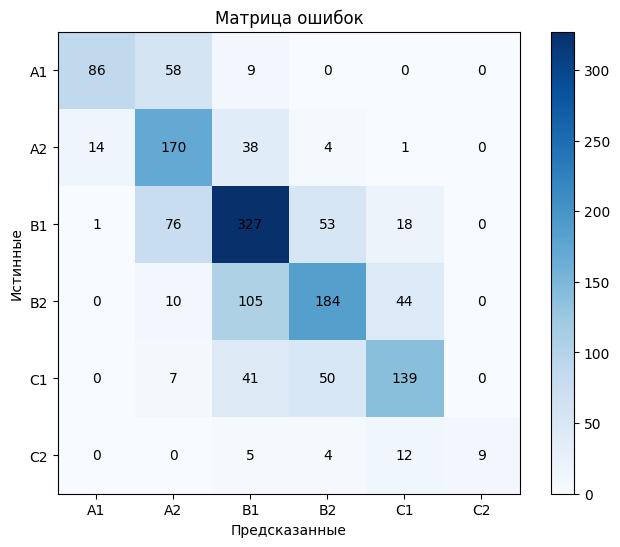

In [11]:
visualize_cm(true_labels, predictions)

## корейский

In [12]:
c2 = pd.read_csv('c2_augmented_one_times_translated_ko.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.044300,0.942339
2,0.527100,1.020477
3,0.141200,1.419341


Обучение завершено за 327.54 секунд (0:05:27)


In [13]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6266
F1 Micro: 0.6266
F1 Macro: 0.5880
F1 Weighted: 0.6250
MAE: 0.4437
              precision    recall  f1-score   support

           1       0.88      0.54      0.67       153
           2       0.52      0.76      0.62       227
           3       0.63      0.67      0.65       475
           4       0.64      0.56      0.60       343
           5       0.64      0.61      0.62       237
           6       0.88      0.23      0.37        30

    accuracy                           0.63      1465
   macro avg       0.70      0.56      0.59      1465
weighted avg       0.65      0.63      0.62      1465



0.6266
0.6266
0.5880
0.6250
0.4437
327.54


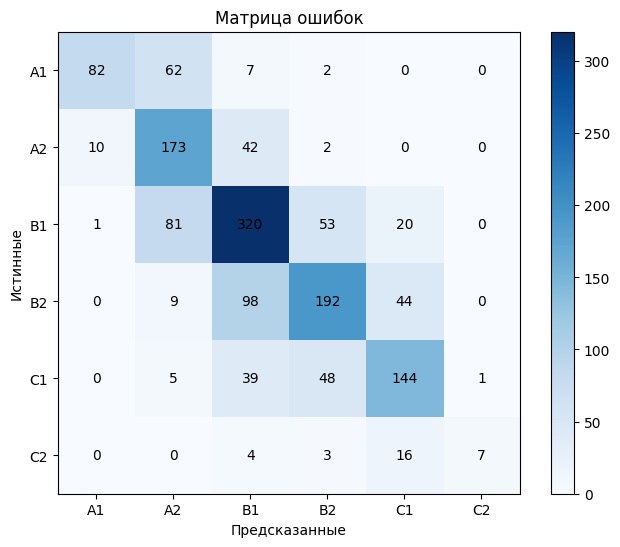

In [14]:
visualize_cm(true_labels, predictions)

## зулу

In [15]:
c2 = pd.read_csv('c2_augmented_one_times_translated_zu.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.035100,0.935266
2,0.523900,1.004284
3,0.123600,1.427143


Обучение завершено за 336.39 секунд (0:05:36)


In [16]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6280
F1 Micro: 0.6280
F1 Macro: 0.5854
F1 Weighted: 0.6264
MAE: 0.4375
              precision    recall  f1-score   support

           1       0.87      0.52      0.65       153
           2       0.54      0.74      0.62       227
           3       0.65      0.67      0.66       475
           4       0.60      0.60      0.60       343
           5       0.64      0.59      0.62       237
           6       0.78      0.23      0.36        30

    accuracy                           0.63      1465
   macro avg       0.68      0.56      0.59      1465
weighted avg       0.64      0.63      0.63      1465



0.6280
0.6280
0.5854
0.6264
0.4375
336.39


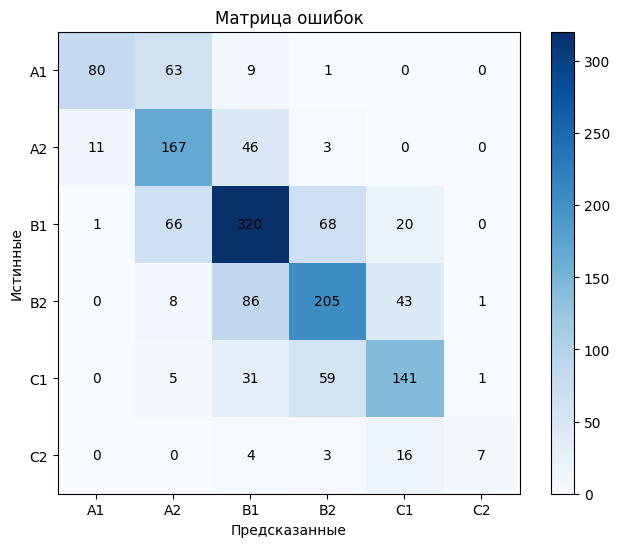

In [17]:
visualize_cm(true_labels, predictions)

## сербский

In [18]:
c2 = pd.read_csv('c2_augmented_one_times_translated_sr.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.039700,0.937392
2,0.519700,0.999364
3,0.124600,1.444483


Обучение завершено за 328.00 секунд (0:05:27)


In [19]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6273
F1 Micro: 0.6273
F1 Macro: 0.5829
F1 Weighted: 0.6247
MAE: 0.4355
              precision    recall  f1-score   support

           1       0.90      0.46      0.61       153
           2       0.53      0.73      0.61       227
           3       0.64      0.69      0.66       475
           4       0.62      0.59      0.60       343
           5       0.65      0.60      0.62       237
           6       1.00      0.23      0.38        30

    accuracy                           0.63      1465
   macro avg       0.72      0.55      0.58      1465
weighted avg       0.65      0.63      0.62      1465



0.6273
0.6273
0.5829
0.6247
0.4355
328.00


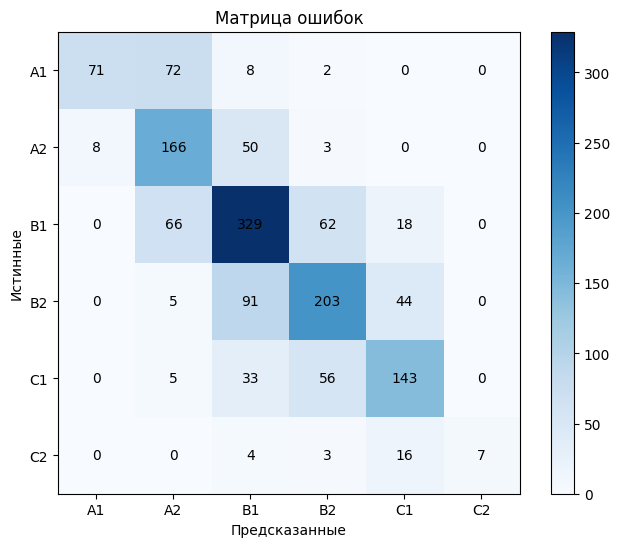

In [20]:
visualize_cm(true_labels, predictions)

## персидский

In [21]:
c2 = pd.read_csv('c2_augmented_one_times_translated_fa.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.030200,0.933501
2,0.511700,0.989707
3,0.132400,1.421000


Обучение завершено за 327.40 секунд (0:05:27)


In [22]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6334
F1 Micro: 0.6334
F1 Macro: 0.5859
F1 Weighted: 0.6302
MAE: 0.4341
              precision    recall  f1-score   support

           1       0.90      0.46      0.61       153
           2       0.53      0.73      0.61       227
           3       0.63      0.72      0.67       475
           4       0.65      0.57      0.61       343
           5       0.65      0.64      0.64       237
           6       0.88      0.23      0.37        30

    accuracy                           0.63      1465
   macro avg       0.71      0.56      0.59      1465
weighted avg       0.66      0.63      0.63      1465



0.6334
0.6334
0.5859
0.6302
0.4341
327.40


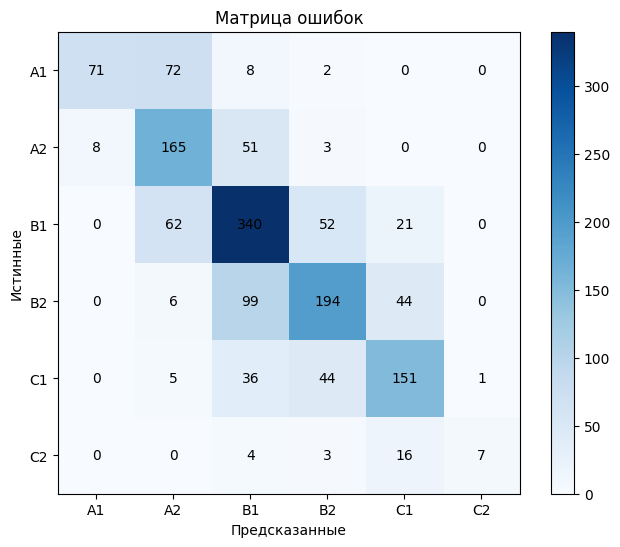

In [23]:
visualize_cm(true_labels, predictions)

## турецкий

In [24]:
c2 = pd.read_csv('c2_augmented_one_times_translated_tr.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.033600,0.934835
2,0.529300,1.023900
3,0.131500,1.436170


Обучение завершено за 327.96 секунд (0:05:27)


In [25]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6266
F1 Micro: 0.6266
F1 Macro: 0.5949
F1 Weighted: 0.6241
MAE: 0.4403
              precision    recall  f1-score   support

           1       0.87      0.47      0.61       153
           2       0.53      0.74      0.62       227
           3       0.63      0.71      0.67       475
           4       0.63      0.55      0.59       343
           5       0.64      0.61      0.62       237
           6       1.00      0.30      0.46        30

    accuracy                           0.63      1465
   macro avg       0.72      0.56      0.59      1465
weighted avg       0.65      0.63      0.62      1465



0.6266
0.6266
0.5949
0.6241
0.4403
327.96


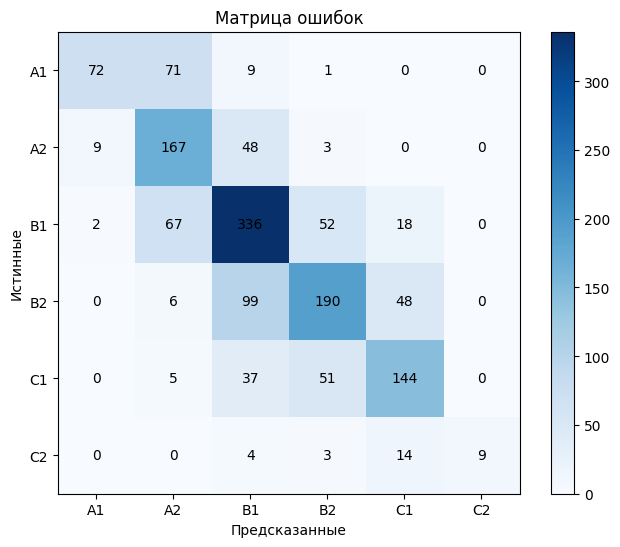

In [26]:
visualize_cm(true_labels, predictions)

## арабский

In [27]:
c2 = pd.read_csv('c2_augmented_one_times_translated_ar.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.042800,0.942514
2,0.530300,0.996506
3,0.134700,1.400437


Обучение завершено за 327.73 секунд (0:05:27)


In [28]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6259
F1 Micro: 0.6259
F1 Macro: 0.5820
F1 Weighted: 0.6233
MAE: 0.4403
              precision    recall  f1-score   support

           1       0.90      0.46      0.61       153
           2       0.52      0.75      0.61       227
           3       0.63      0.69      0.66       475
           4       0.63      0.58      0.61       343
           5       0.65      0.59      0.62       237
           6       1.00      0.23      0.38        30

    accuracy                           0.63      1465
   macro avg       0.72      0.55      0.58      1465
weighted avg       0.65      0.63      0.62      1465



0.6259
0.6259
0.5820
0.6233
0.4403
327.73


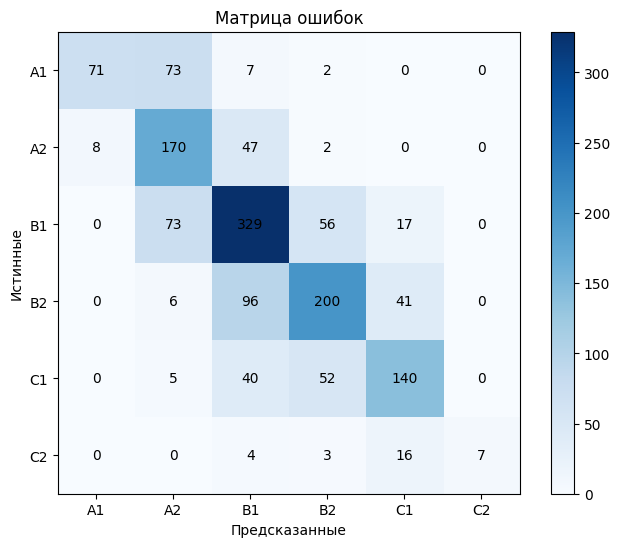

In [29]:
visualize_cm(true_labels, predictions)

## африкаанс

In [30]:
c2 = pd.read_csv('c2_augmented_one_times_translated_af.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.034600,0.946028
2,0.523100,1.015966
3,0.132000,1.403497


Обучение завершено за 327.66 секунд (0:05:27)


In [31]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6225
F1 Micro: 0.6225
F1 Macro: 0.5788
F1 Weighted: 0.6200
MAE: 0.4430
              precision    recall  f1-score   support

           1       0.90      0.46      0.61       153
           2       0.52      0.74      0.61       227
           3       0.63      0.68      0.66       475
           4       0.62      0.59      0.61       343
           5       0.64      0.59      0.61       237
           6       1.00      0.23      0.38        30

    accuracy                           0.62      1465
   macro avg       0.72      0.55      0.58      1465
weighted avg       0.65      0.62      0.62      1465



0.6225
0.6225
0.5788
0.6200
0.4430
327.66


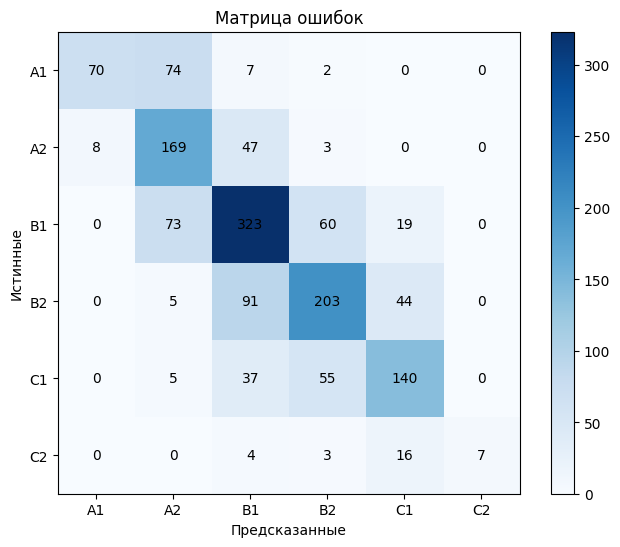

In [32]:
visualize_cm(true_labels, predictions)

## латинский

In [33]:
c2 = pd.read_csv('c2_augmented_one_times_translated_la.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.039500,0.950513
2,0.511300,1.011665
3,0.130800,1.418285


Обучение завершено за 327.29 секунд (0:05:27)


In [34]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6205
F1 Micro: 0.6205
F1 Macro: 0.5747
F1 Weighted: 0.6168
MAE: 0.4471
              precision    recall  f1-score   support

           1       0.89      0.44      0.59       153
           2       0.52      0.74      0.61       227
           3       0.62      0.71      0.66       475
           4       0.62      0.57      0.59       343
           5       0.65      0.57      0.61       237
           6       1.00      0.23      0.38        30

    accuracy                           0.62      1465
   macro avg       0.72      0.54      0.57      1465
weighted avg       0.65      0.62      0.62      1465



0.6205
0.6205
0.5747
0.6168
0.4471
327.29


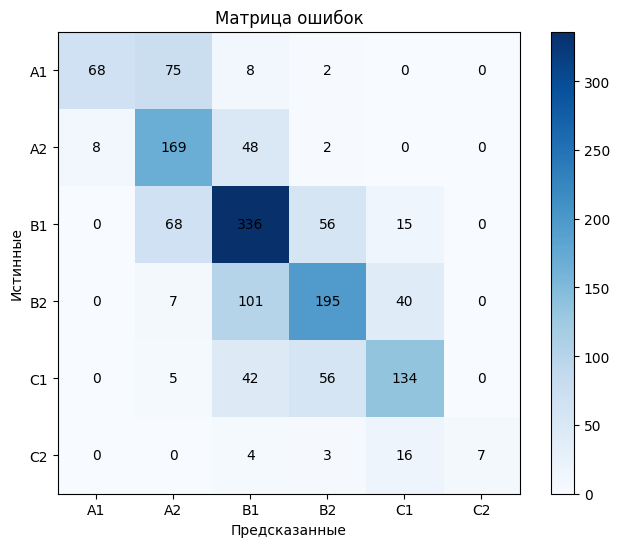

In [35]:
visualize_cm(true_labels, predictions)

## греческий

In [36]:
c2 = pd.read_csv('c2_augmented_one_times_translated_el.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.034800,0.950074
2,0.522200,1.015141
3,0.135600,1.422824


Обучение завершено за 327.65 секунд (0:05:27)


In [37]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6164
F1 Micro: 0.6164
F1 Macro: 0.5757
F1 Weighted: 0.6136
MAE: 0.4539
              precision    recall  f1-score   support

           1       0.90      0.47      0.62       153
           2       0.52      0.74      0.61       227
           3       0.61      0.69      0.65       475
           4       0.63      0.55      0.59       343
           5       0.65      0.58      0.61       237
           6       1.00      0.23      0.38        30

    accuracy                           0.62      1465
   macro avg       0.72      0.54      0.58      1465
weighted avg       0.64      0.62      0.61      1465



0.6164
0.6164
0.5757
0.6136
0.4539
327.65


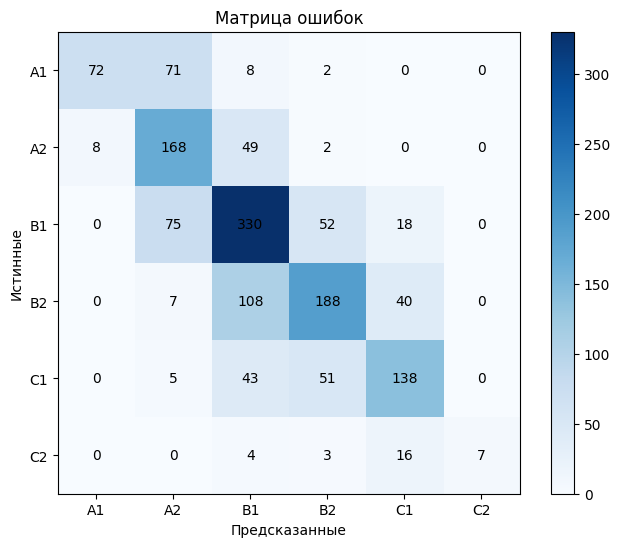

In [38]:
visualize_cm(true_labels, predictions)

# Перевод 3 раза

In [17]:
c2 = pd.read_csv('c2_augmented_three_times_translated.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.044900,0.937651
2,0.515400,1.008191
3,0.132900,1.406740


Обучение завершено за 327.91 секунд (0:05:27)


In [18]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6266
F1 Micro: 0.6266
F1 Macro: 0.5820
F1 Weighted: 0.6246
MAE: 0.4423
              precision    recall  f1-score   support

           1       0.90      0.49      0.64       153
           2       0.53      0.74      0.62       227
           3       0.63      0.68      0.65       475
           4       0.63      0.57      0.60       343
           5       0.65      0.62      0.63       237
           6       0.70      0.23      0.35        30

    accuracy                           0.63      1465
   macro avg       0.67      0.56      0.58      1465
weighted avg       0.65      0.63      0.62      1465



0.6266
0.6266
0.5820
0.6246
0.4423
327.91


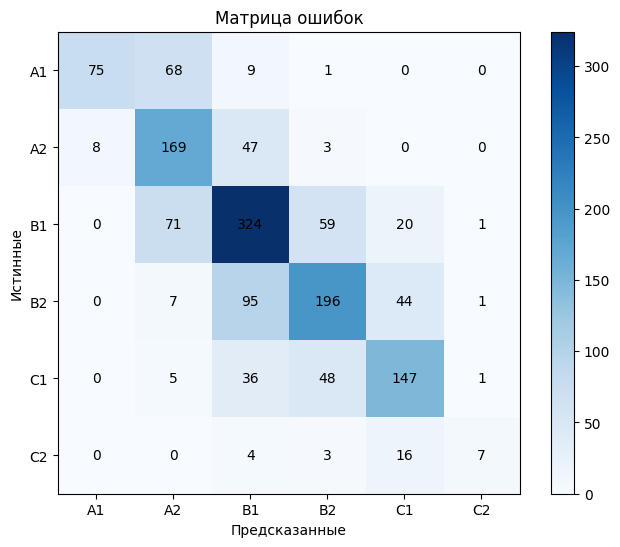

In [19]:
visualize_cm(true_labels, predictions)

# Перевод 5 раз

In [20]:
c2 = pd.read_csv('c2_augmented_five_times_translated.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.046500,0.957114
2,0.526000,0.994518
3,0.130700,1.423106


Обучение завершено за 327.29 секунд (0:05:27)


In [21]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6191
F1 Micro: 0.6191
F1 Macro: 0.5688
F1 Weighted: 0.6154
MAE: 0.4498
              precision    recall  f1-score   support

           1       0.90      0.47      0.62       153
           2       0.52      0.74      0.61       227
           3       0.61      0.71      0.66       475
           4       0.63      0.56      0.60       343
           5       0.66      0.55      0.60       237
           6       1.00      0.20      0.33        30

    accuracy                           0.62      1465
   macro avg       0.72      0.54      0.57      1465
weighted avg       0.65      0.62      0.62      1465



0.6191
0.6191
0.5688
0.6154
0.4498
327.29


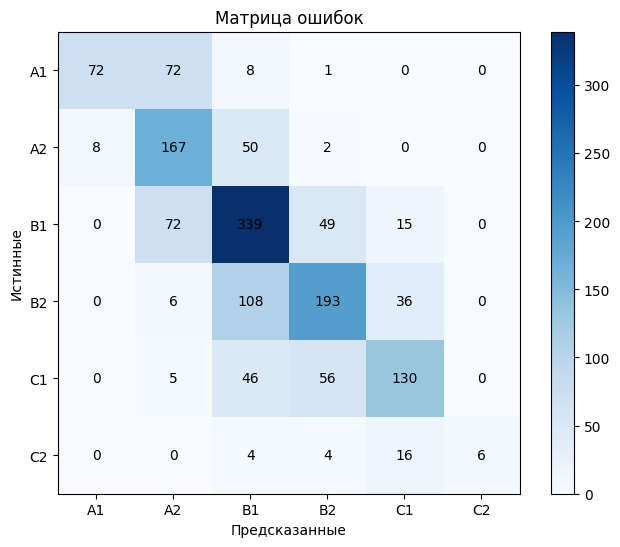

In [22]:
visualize_cm(true_labels, predictions)

# Перевод 7 раз

In [9]:
c2 = pd.read_csv('c2_augmented_seven_times_translated.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.045900,0.973466
2,0.548900,0.994530
3,0.150600,1.400926


Обучение завершено за 327.66 секунд (0:05:27)


In [10]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6130
F1 Micro: 0.6130
F1 Macro: 0.5754
F1 Weighted: 0.6092
MAE: 0.4628
              precision    recall  f1-score   support

           1       0.91      0.44      0.60       153
           2       0.50      0.78      0.61       227
           3       0.60      0.71      0.65       475
           4       0.65      0.53      0.59       343
           5       0.66      0.53      0.59       237
           6       1.00      0.27      0.42        30

    accuracy                           0.61      1465
   macro avg       0.72      0.54      0.58      1465
weighted avg       0.65      0.61      0.61      1465



0.6130
0.6130
0.5754
0.6092
0.4628
327.66


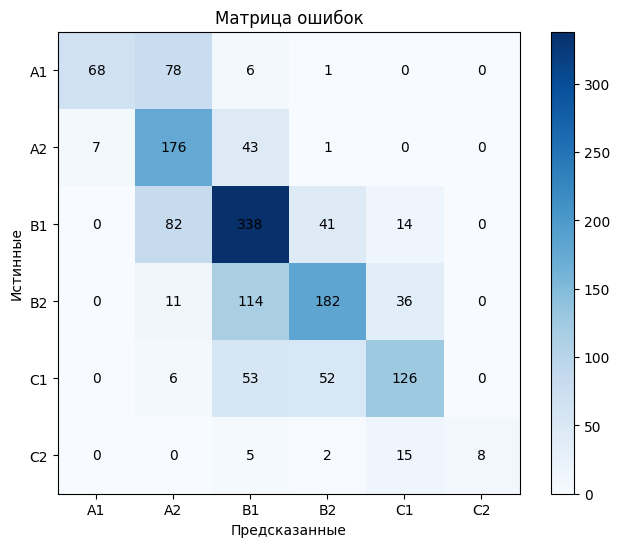

In [11]:
visualize_cm(true_labels, predictions)

# Перевод 9 раз

In [12]:
c2 = pd.read_csv('c2_augmented_nine_times_translated.csv')
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 5977
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,1.050900,0.943121
2,0.519200,1.021922
3,0.130300,1.472782


Обучение завершено за 328.34 секунд (0:05:28)


In [13]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6246
F1 Micro: 0.6246
F1 Macro: 0.5793
F1 Weighted: 0.6220
MAE: 0.4403
              precision    recall  f1-score   support

           1       0.90      0.45      0.60       153
           2       0.53      0.74      0.62       227
           3       0.64      0.67      0.66       475
           4       0.60      0.61      0.61       343
           5       0.66      0.60      0.63       237
           6       0.88      0.23      0.37        30

    accuracy                           0.62      1465
   macro avg       0.70      0.55      0.58      1465
weighted avg       0.65      0.62      0.62      1465



0.6246
0.6246
0.5793
0.6220
0.4403
328.34


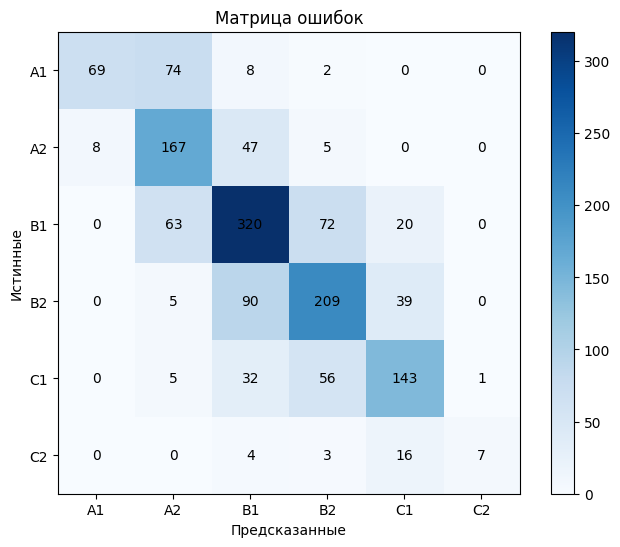

In [14]:
visualize_cm(true_labels, predictions)

# Все сразу

In [23]:
c2 = pd.DataFrame()

for number in ['one', 'three', 'five']:
    df = pd.read_csv(f'c2_augmented_{number}_times_translated.csv')
    c2 = pd.concat([c2, df])


c2

,text,augmented-text
0,"3:38–3:54 Собственно, сама по себе радиация не...",3:38–3:54 На самом деле радиация не заразна. Н...
1,Недавно компания Uber объявила об инвестиции о...,Uber недавно объявил об инвестициях в миллиард...
2,"Множество повестей: «Двойник», «Дядюшкин сон»,...",В творчестве великого писателя было много расс...
3,Встречи одноклассников и одногруппников превра...,Встречи одноклассников и одноклассников превра...
4,Самопрезентация — как главная черта времени и ...,Самопрезентация – это одновременно визитная ка...
...,...,...
115,00:00:24 А сегодня испытания. 13 участников. Ж...,00:00:24 Сегодняшний обзор. 13 участников. опр...
116,«Прома» способна предложить дилерам вполне бож...,«Прома» реализует систему кооперативных скидок...
117,Tesla — не единственный игрок на рынке: больши...,"Tesla - Ford, Honda, Toyota, Nissan, Volvo, BM..."
118,"Понятно, что среди крупнейших стран – поставщи...","Понятно, что Китай и Индия входят в число круп..."


In [26]:
model, val_dataset, train_time = fit(c2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sberbank-ai/ruBert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель инициализирована
Обучающая выборка с аугментациями: 6217
Валидационная выборка без аугментации: 1465


Epoch,Training Loss,Validation Loss
1,0.987900,0.923464
2,0.466700,0.908144
3,0.145500,1.327433


Обучение завершено за 333.39 секунд (0:05:33)


In [27]:
true_labels, predictions = predict(model, val_dataset, device, train_time)

Accuracy: 0.6696
F1 Micro: 0.6696
F1 Macro: 0.6617
F1 Weighted: 0.6692
MAE: 0.3980
              precision    recall  f1-score   support

           1       0.88      0.70      0.78       153
           2       0.63      0.65      0.64       227
           3       0.64      0.76      0.69       475
           4       0.66      0.59      0.63       343
           5       0.67      0.64      0.65       237
           6       0.87      0.43      0.58        30

    accuracy                           0.67      1465
   macro avg       0.73      0.63      0.66      1465
weighted avg       0.68      0.67      0.67      1465



0.6696
0.6696
0.6617
0.6692
0.3980
333.39


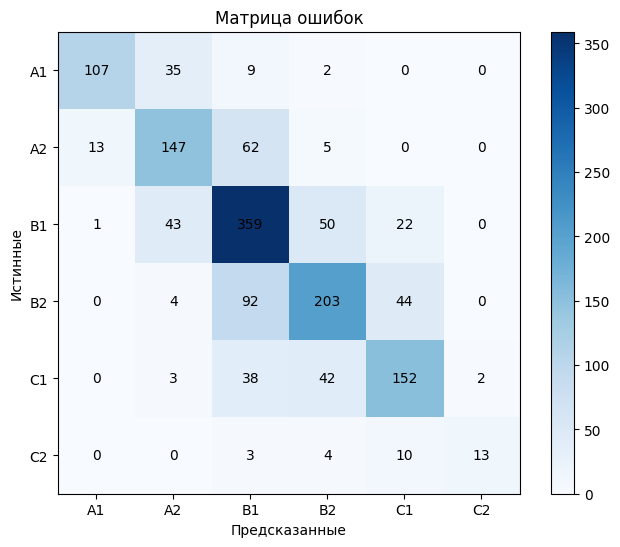

In [28]:
visualize_cm(true_labels, predictions)